# 1. 이미지 불러오기

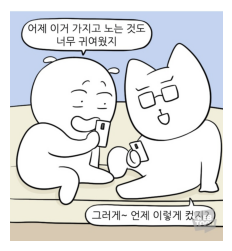

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "./images/webtoon1.jpeg"
image = Image.open(image_path)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.axis("off")
plt.show()

# 2. OCR로 이미지에서 텍스트 추출하기

In [14]:
from paddleocr import PaddleOCR

# paddleocr 라이브러리로 OCR 구현
ocr = PaddleOCR(
    lang='korean',
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

# 추론할 이미지 넣기
results = ocr.predict(input=image_path)

for res in results:
    res.print()
    res.save_to_img("output")
    res.save_to_json("output")

Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\user\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('korean_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\user\.paddlex\official_models\korean_PP-OCRv5_mobile_rec`.
{'res': {'input_path': './images/webtoon1.jpeg', 'page_index': None, 'model_settings': {'use_doc_preprocessor': True, 'use_textline_orientation': False}, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'model_settings': {'use_doc_orientation_classify': False, 'use_doc_unwarping': False}, 'angle': -1}, 'dt_polys': array([[[ 50,  35],
        ...,
        [ 50,  84]],

       ...,

       [[260, 640],
        ...,
        [260, 689]]], shape=(3, 4, 2), dtype=int16), 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_s

In [15]:
print(type(results))
print(len(results))
print(results[0])
result = results[0]

<class 'list'>
1
{'input_path': './images/webtoon1.jpeg', 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[253, ..., 254],
        ...,
        [253, ..., 254]],

       ...,

       [[178, ..., 216],
        ...,
        [178, ..., 216]]], shape=(750, 690, 3), dtype=uint8), 'model_settings': {'use_doc_orientation_classify': False, 'use_doc_unwarping': False}, 'angle': -1, 'rot_img': array([[[253, ..., 254],
        ...,
        [253, ..., 254]],

       ...,

       [[178, ..., 216],
        ...,
        [178, ..., 216]]], shape=(750, 690, 3), dtype=uint8), 'output_img': array([[[253, ..., 254],
        ...,
        [253, ..., 254]],

       ...,

       [[178, ..., 216],
        ...,
        [178, ..., 216]]], shape=(750, 690, 3), dtype=uint8)}, 'dt_polys': [array([[50, 35],
       ...,
       [50, 84]], shape=(4, 2), dtype=int16), array([[144,  76],
       ...,
       [144, 122]], shape=(4, 2), dtype=int16), array([[260, 640]

In [16]:
result["input_path"]

'./images/webtoon1.jpeg'

In [17]:
result.keys()

dict_keys(['input_path', 'page_index', 'doc_preprocessor_res', 'dt_polys', 'model_settings', 'text_det_params', 'text_type', 'text_rec_score_thresh', 'return_word_box', 'rec_texts', 'rec_scores', 'rec_polys', 'vis_fonts', 'textline_orientation_angles', 'rec_boxes'])

In [18]:
result["rec_polys"]

[array([[50, 35],
        ...,
        [50, 84]], shape=(4, 2), dtype=int16),
 array([[144,  76],
        ...,
        [144, 122]], shape=(4, 2), dtype=int16),
 array([[260, 640],
        ...,
        [260, 689]], shape=(4, 2), dtype=int16)]

In [19]:
result["rec_texts"]

['어제 이거 가지고 노는 것도', '너무 귀여웠지', '그러게~언제 이렇게 컸지']

In [20]:
result["rec_boxes"]

array([[ 50, ...,  84],
       ...,
       [260, ..., 691]], shape=(3, 4), dtype=int16)

# OCR 활용

- 이미지에서 박스위치를 찾아서 그 말풍선에 있는 텍스트를 없애고 새로운 텍스트를 넣어보기

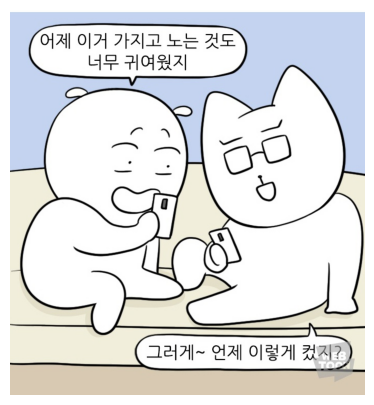

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "./images/webtoon1.jpeg"
image = Image.open(image_path)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.show()

In [51]:
from PIL import ImageDraw, ImageFont

# 그릴 준비하기
image_new = image.copy()
draw = ImageDraw.Draw(image_new)

font_path = "C:/Windows/Fonts/malgun.ttf"
font = ImageFont.truetype(font_path, 42)

In [24]:
# 박스 생김새 확인하기(x1, y1, x2, y2) --좌상 우하단 좌표
result["rec_boxes"][0].tolist()

[50, 35, 444, 84]

In [52]:
mytext_list = ["뭐하세요?", "장난해?", "아닝"]

In [53]:
for idx, (x1, y1, x2, y2) in enumerate(result["rec_boxes"]):
    print(x1, y1, x2, y2)
    draw.rectangle([x1, y1, x2, y2], width=2, fill='white')
    draw.text([x1, y1, x2, y2], mytext_list[idx], font=font, fill="black")

50 35 444 84
144 76 350 124
260 640 660 691


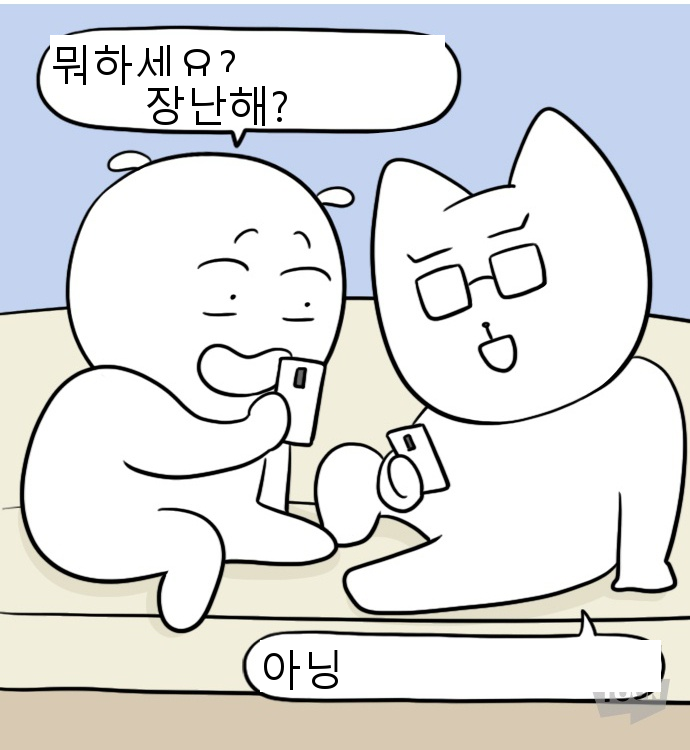

In [54]:
image_new

## OCR 활용 2 - 번역 넣어보기

In [63]:
# uv add translate

from translate import Translator

translator = Translator(from_lang="ko", to_lang="en")

document_result = []

for sent in result["rec_texts"]:
    print(sent)
    translation = translator.translate(sent)
    print(translation)

    document_result.append(translation)

document_result

어제 이거 가지고 노는 것도
Playing with this yesterday
너무 귀여웠지
It was so cute
그러게~언제 이렇게 컸지
Yeah ~ When did I grow up like this?


['Playing with this yesterday',
 'It was so cute',
 'Yeah ~ When did I grow up like this?']

In [72]:
from PIL import ImageDraw, ImageFont

# 그릴 준비하기
image_new2 = image.copy()
draw = ImageDraw.Draw(image_new2)

font_path = "C:/Windows/Fonts/malgun.ttf"
font = ImageFont.truetype(font_path, 30)

In [73]:
for idx, (x1, y1, x2, y2) in enumerate(result["rec_boxes"]):
    print(x1, y1, x2, y2)
    draw.rectangle([x1, y1, x2, y2], width=2, fill='white')
    draw.text([x1, y1, x2, y2], document_result[idx], font=font, fill="black")

50 35 444 84
144 76 350 124
260 640 660 691


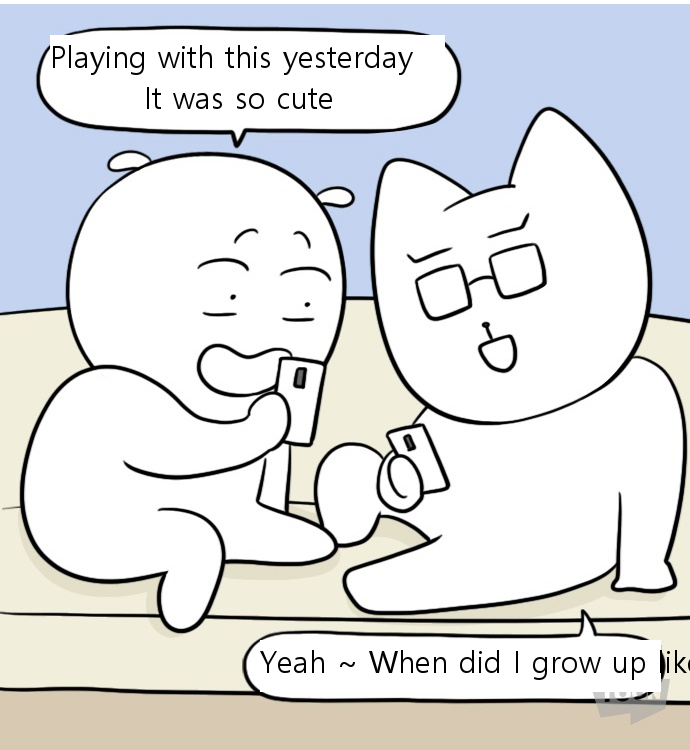

In [74]:
image_new2

1. OCR은 무엇인가?
2. OCR 라이브러리들은 뭐가 있을까?
3. PaddleOCR의 출력에서 뭘 보면 되는가?
4. OCR로 추출된 텍스트를 이미지에서 바꿀 수 있는 방법이 무엇인가?
5. OCR로 뭘 할 수 있을까?